# zagg write pipeline

Lambda fan-out from the shard maps built in `01_query`: dispatch, futures, cost. Same shardmap, different aggregations; with and without the strict-AOI mask; California at o8 with cost telemetry.

In [1]:
# %pip install "zagg[catalog,viz]"

import io
import json
import logging
import os
import re
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from importlib import resources
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import Markdown

from zagg import notebook as znb
from zagg.catalog import load_polygon
from zagg.catalog.shardmap import ShardMap
from zagg.catalog.sources import Catalog
from zagg.client import Run
from zagg.config import default_config
from zagg.data import demo_aoi
from zagg.grids import from_config
from zagg.notebook import format_max_cost, max_cost_preview
from zagg import runner as _runner
from zagg.client import ShardError
from zagg.dispatch import LAMBDA_PRICE_PER_GB_SEC


In [2]:
# prefer the 'nasa' profile when it exists (laptop); ambient creds otherwise (hub role)
import botocore.session as _bs

if "nasa" in (_bs.Session().full_config.get("profiles") or {}):
    os.environ.setdefault("AWS_PROFILE", "nasa")
logging.basicConfig(level=logging.INFO, format="%(name)s: %(message)s")
for noisy in ("botocore", "boto3", "urllib3", "s3transfer", "stac_geoparquet"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

OUT = Path("outputs")
STORE = "s3://sliderule-public/zagg-demo"

timings = {}


class stage:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = round(time.perf_counter() - self.t0, 2)
        print(f"[{self.name}] {timings[self.name]:.1f}s")

## The aggregation template, block by block

In [3]:
raw = (resources.files("zagg.configs") / "atl03_tdigest_healpix_hive.yaml").read_text()


def yaml_block(text, name):
    block = re.search(rf"^{name}:.*?(?=^\w|\Z)", text, re.S | re.M).group(0)
    clean = "\n".join(l for l in block.splitlines() if not l.strip().startswith("#"))
    return Markdown(f"```yaml\n{clean}\n```")

### `data_source` — what to read

- h5coro reads each ATL03 granule directly over S3 by byte range — nothing is downloaded; six beam groups each contribute photon lat/lon/height.
- `index: {backend: inline}` selects the virtual chunk-index for the byte-range reads (vs the pure `hierarchical` metadata walk).
- `filters` drops TEP returns; `levels` + `read_plan` declare the segment→photon index link, so a worker fetches only the segments crossing its shard (`pad: 1`).

In [4]:
yaml_block(raw, "data_source")

```yaml
data_source:
  granule_workers: 4
  reader: h5coro
  driver: s3
  index:
    backend: inline            # virtual chunk-index for the byte-range reads;
  groups: [gt1l, gt1r, gt2l, gt2r, gt3l, gt3r]
  coordinates:
    latitude: "/{group}/heights/lat_ph"
    longitude: "/{group}/heights/lon_ph"
  variables:
    h_ph: "/{group}/heights/h_ph"
  filters:
    - dataset: "/{group}/heights/signal_conf_ph"
      column: 0                  # land surface type; TEP is uniform across columns
      op: ne
      value: -2
  base_level: photons
  levels:
    photons:
      path: "/{group}/heights"
      coordinates: {latitude: lat_ph, longitude: lon_ph}
      link: null
    segments:
      path: "/{group}/geolocation"
      coordinates: {latitude: reference_photon_lat, longitude: reference_photon_lon}
      link:
        to: photons
        index_beg: "/{group}/geolocation/ph_index_beg"
        count: "/{group}/geolocation/segment_ph_cnt"
        index_base: 1            # ATL03 ph_index_beg is 1-based per the v3 dict
  read_plan:
    spatial_index: segments
    pad: 1                       # one segment of padding on each side per #43

```

### `aggregation` — what to compute

- One output field per entry: `count` is a dense per-cell int32; `h_tdigest` is a ragged per-cell t-digest sketch (`delta: 256` centroid budget) from which any quantile is recovered at read time.
- `streaming: {mode: spill}` bounds worker memory: reads spill to `/tmp` partitions and aggregate in one pass after the reads (pooled-identical in the single-block regime; `merge` is the incremental-fold alternative for mergeable reducers).
- Swapping this block changes the science without touching the read or the layout — demoed below with the located variant.

In [5]:
yaml_block(raw, "aggregation")

```yaml
aggregation:
  streaming:
    mode: spill                # bounded read buffers spilled to /tmp partitions, one
  coordinates:
    morton:
      dtype: uint64
      fill_value: 0
  variables:
    count:
      function: len
      source: h_ph
      dtype: int32
      fill_value: 0
    h_tdigest:
      kind: ragged
      function: "zagg.stats.tdigest.build_tdigest"
      source: h_ph
      inner_shape: [2]
      params:
        delta: 8192              # leaf centroid budget: loss-free bound (issues #414/#424)
      overview_delta: 512        # pyramid-fold budget: ~1/512 accuracy (issue #424)
      dtype: float32
      fill_value: 0

```

### `output` — where it lands

- HEALPix nested grid: `child_order: 19` (~10 m cells); `parent_order: 9` is the dispatch shard (1024×1024 cells, one Lambda invoke each); `chunk_inner: 13` bundles 256 inner chunks into one sharded zarr object.
- `store_layout: hive`: every shard writes its own self-describing leaf zarr; `pyramid: false` keeps the overview sweep off.

In [6]:
yaml_block(raw, "output")

```yaml
output:
  grid:
    type: healpix
    indexing_scheme: nested
    parent_order: 9              # shard / dispatch unit: 4^(19-9) = 1024x1024 cells
    chunk_inner: 13              # inner Zarr chunk: 4^(19-13) = 64x64 cells (K=256 per shard)
    sharded: true                # one ShardingCodec object per array per leaf
    child_order: 19              # leaf cell resolution (~10 m)
  store_layout: hive             # each dispatched shard writes its own leaf zarr
  pyramid: false                 # overview sweep off (untested at demo scale, issue #201)

```

### `worker` — which Lambda runs it

- Selects the pre-provisioned variant: `memory` (2048/4096/8192 MB → `process-shard-<memory>`), `extra_disk: true` picks the `-disk` twin (memory+2048 MB of `/tmp`), which backs the spill partitions.
- The pre-invoke cost ceiling and the metered post-run rollup both key off this block.

In [7]:
yaml_block(raw, "worker")

```yaml
worker:
  memory: 4096                   # pre-provisioned Lambda variant, MB (2048|4096|8192) --
  extra_disk: true               # the -disk twin: memory+2048 MB of /tmp, backing the
```

## SERC — four variants, dispatched in parallel

Each `dispatch()` returns after its setup handshake and `progress_async()` keeps the kernel free, so all four fleets launch back-to-back; one join below blocks once, then the summary compares them.

In [8]:
def clear_store(prefix):
    """Delete every object under an s3://bucket/prefix (paged batch deletes)."""
    bucket, _, key = prefix.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    n = 0
    for page in s3.get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=key):
        objs = [{"Key": o["Key"]} for o in page.get("Contents", [])]
        for i in range(0, len(objs), 1000):
            s3.delete_objects(Bucket=bucket, Delete={"Objects": objs[i : i + 1000], "Quiet": True})
        n += len(objs)
    return n


# SERC demo stores are wiped for a clean re-run (the hive template guard refuses
# re-templating over a populated digit tree); California below is KEPT, never wiped.
for name in (
    "serc_tdigest",
    "serc_tdigest_aoi",
    "serc_tdigest_located",
    "serc_tdigest_strata",
    "s2_serc_2025",
):
    print(f"{name}.zarr: {clear_store(f'{STORE}/{name}.zarr')} objects cleared")

DELTA_UNIFORM = 4096  # ONE centroid budget across every demo store (espg ruling
#                       2026-08-17: no divergence, fits the 4096 tier fleet-wide;
#                       supersedes the packaged 8192 template default here)


def set_uniform_delta(cfg):
    """Pin every ragged digest field to the uniform demo-wide delta."""
    for _m in cfg.aggregation["variables"].values():
        if _m.get("kind") == "ragged":
            _m.setdefault("params", {})["delta"] = DELTA_UNIFORM
    return cfg


serc_tdigest.zarr: 103 objects cleared
serc_tdigest_aoi.zarr: 111 objects cleared
serc_tdigest_located.zarr: 119 objects cleared
serc_tdigest_strata.zarr: 151 objects cleared
s2_serc_2025.zarr: 0 objects cleared


In [9]:
serc_map = str(OUT / "shardmap_atl03_serc_o9.json")
config = default_config("atl03_tdigest_healpix_hive")

set_uniform_delta(config)
run = Run.from_config(config, shardmap=serc_map, store=f"{STORE}/serc_tdigest.zarr", overwrite=True)
run

Run(4 shards -> 's3://sliderule-public/zagg-demo/serc_tdigest.zarr', function='process-shard-4096-disk', region='us-west-2')

In [10]:
traces = {}


def track(name, handle):
    """Live bar + per-run completion timeline (latency = first entry, wall = last)."""
    t0 = time.perf_counter()
    times = traces.setdefault(name, [])

    def _drain():
        from tqdm.auto import tqdm

        for _ in tqdm(handle.as_completed(), total=len(handle), desc=name, unit="shard"):
            times.append(time.perf_counter() - t0)

    threading.Thread(target=_drain, daemon=True).start()
    return handle


t0_run = time.perf_counter()
handle = run.dispatch()  # returns after the setup handshake; every shard is a Future
track("combined", handle)  # live bar on a daemon thread -- the kernel is NOT blocked
handle.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
earthaccess.auth: You're now authenticated with NASA Earthdata Login
earthaccess.auth: Using token with expiration date 08/27/2026
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

In [11]:
handle.status() | {
    "cost_so_far_usd": round(handle.cost_usd(), 4)
}  # rerun at will while the fleet works

combined:   0%|          | 0/4 [00:00<?, ?shard/s]

{'pending': 4, 'ok': 0, 'failed': 0, 'cost_so_far_usd': 0.0}

## SERC — same pipeline, with the strict-AOI mask

In [12]:
cat_serc = Catalog.from_geoparquet(str(OUT / "catalog_atl03_serc.parquet"))
serc_parts = load_polygon(demo_aoi("serc"))

masked_config = default_config("atl03_tdigest_healpix_hive")
masked_config.output["aoi_mask"] = True
grid = from_config(masked_config)

sm_masked = ShardMap.build(cat_serc, grid, region=serc_parts, mortie_order=9)
sm_masked.to_json(str(OUT / "shardmap_atl03_serc_o9_aoi.json"))

# in-AOI cell fraction per shard: edge shards are mostly outside the flight box
{
    grid.shard_label(int(k)): round(
        float(grid.aoi_mask_from_payload(m, grid.children(int(k))).mean()), 3
    )
    for k, m in zip(sm_masked.shard_keys, sm_masked.aoi_mask)
}
set_uniform_delta(masked_config)


PipelineConfig(data_source={'granule_workers': 4, 'reader': 'h5coro', 'driver': 's3', 'index': {'backend': 'inline'}, 'groups': ['gt1l', 'gt1r', 'gt2l', 'gt2r', 'gt3l', 'gt3r'], 'coordinates': {'latitude': '/{group}/heights/lat_ph', 'longitude': '/{group}/heights/lon_ph'}, 'variables': {'h_ph': '/{group}/heights/h_ph'}, 'filters': [{'dataset': '/{group}/heights/signal_conf_ph', 'column': 0, 'op': 'ne', 'value': -2}], 'base_level': 'photons', 'levels': {'photons': {'path': '/{group}/heights', 'coordinates': {'latitude': 'lat_ph', 'longitude': 'lon_ph'}, 'link': None}, 'segments': {'path': '/{group}/geolocation', 'coordinates': {'latitude': 'reference_photon_lat', 'longitude': 'reference_photon_lon'}, 'link': {'to': 'photons', 'index_beg': '/{group}/geolocation/ph_index_beg', 'count': '/{group}/geolocation/segment_ph_cnt', 'index_base': 1}}}, 'read_plan': {'spatial_index': 'segments', 'pad': 1}}, aggregation={'streaming': {'mode': 'spill'}, 'coordinates': {'morton': {'dtype': 'uint64', '

In [13]:
run_masked = Run.from_config(
    masked_config,
    shardmap=str(OUT / "shardmap_atl03_serc_o9_aoi.json"),
    store=f"{STORE}/serc_tdigest_aoi.zarr",
    overwrite=True,
)
handle_masked = run_masked.dispatch()
track("aoi_mask", handle_masked)
handle_masked.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


aoi_mask:   0%|          | 0/4 [00:00<?, ?shard/s]

{'pending': 4, 'ok': 0, 'failed': 0}

In [14]:
handle_masked.status() | {
    "cost_so_far_usd": round(handle_masked.cost_usd(), 4)
}  # rerun at will while the fleet works

{'pending': 4, 'ok': 0, 'failed': 0, 'cost_so_far_usd': 0.0}

The mask drops no photons — the masked store additionally carries a per-cell `aoi_mask` bool array, which readers use to clip whole-shard overhang at the AOI edge.

## SERC — same shardmap, different aggregation: located t-digest

Same `build_tdigest` reducer — the single delta is `location: leaf_id`, which adds a per-centroid morton location channel (order-29 photon words folded via `common_ancestor`, stored as the row-aligned `h_tdigest_locations` companion array).

In [15]:
located_config = default_config("atl03_tdigest_healpix_hive")
# graft the located VARIABLES -- coordinates and the streaming block stay the
# template's. Post-#463 those variables also declare the section-8.3 temporal
# companion (per-centroid toc words beside the morton words), so the graft
# must carry the store's clock with them: the per-photon delta_time column and
# the output.time_source declaration it encodes from. A companion without a
# declared clock is a named refusal (spec section 8.3, issue #410).
_located = default_config("atl03_tdigest_located_healpix")
located_config.aggregation["variables"] = _located.aggregation["variables"]
located_config.data_source["variables"]["delta_time"] = "/{group}/heights/delta_time"
located_config.output["time_source"] = _located.output["time_source"]

located_yaml = (resources.files("zagg.configs") / "atl03_tdigest_located_healpix.yaml").read_text()
yaml_block(located_yaml, "aggregation")
set_uniform_delta(located_config)


PipelineConfig(data_source={'granule_workers': 4, 'reader': 'h5coro', 'driver': 's3', 'index': {'backend': 'inline'}, 'groups': ['gt1l', 'gt1r', 'gt2l', 'gt2r', 'gt3l', 'gt3r'], 'coordinates': {'latitude': '/{group}/heights/lat_ph', 'longitude': '/{group}/heights/lon_ph'}, 'variables': {'h_ph': '/{group}/heights/h_ph', 'delta_time': '/{group}/heights/delta_time'}, 'filters': [{'dataset': '/{group}/heights/signal_conf_ph', 'column': 0, 'op': 'ne', 'value': -2}], 'base_level': 'photons', 'levels': {'photons': {'path': '/{group}/heights', 'coordinates': {'latitude': 'lat_ph', 'longitude': 'lon_ph'}, 'link': None}, 'segments': {'path': '/{group}/geolocation', 'coordinates': {'latitude': 'reference_photon_lat', 'longitude': 'reference_photon_lon'}, 'link': {'to': 'photons', 'index_beg': '/{group}/geolocation/ph_index_beg', 'count': '/{group}/geolocation/segment_ph_cnt', 'index_base': 1}}}, 'read_plan': {'spatial_index': 'segments', 'pad': 1}}, aggregation={'streaming': {'mode': 'spill'}, 'c

In [16]:
run_located = Run.from_config(
    located_config, shardmap=serc_map, store=f"{STORE}/serc_tdigest_located.zarr", overwrite=True
)
handle_located = run_located.dispatch()
track("located", handle_located)
handle_located.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

located:   0%|          | 0/4 [00:00<?, ?shard/s]

## SERC — signal/noise strata (the split t-digest)

The production-direction template: TWO digests per cell — `h_tdigest_signal` / `h_tdigest_noise`, split by the per-surface confidence union (`>= 2` on any of the five `signal_conf_ph` columns, declared as column-selected variables in `data_source`) — plus a packed per-cell `composition` lanes field. Both strata also carry `location: leaf_id`, so strata and location compose.

In [17]:
strata_config = default_config("atl03_tdigest_strata_healpix")
strata_config.output = default_config("atl03_tdigest_healpix_hive").output  # same hive grid/layout
strata_config.worker = dict(default_config("atl03_tdigest_healpix_hive").worker)  # 4096-disk
strata_config.aggregation["streaming"] = {"mode": "spill"}  # same spill path as the template
# Temporal companion on both strata (issue #410 / PR #463): per-centroid toc
# words beside the located words, so the read demos can color photons by
# acquisition time. A companion travels with its clock: the per-photon
# delta_time column + the output.time_source declaration (spec section 8.3 --
# a companion without a resolvable clock refuses at the worker; #472 moves
# that refusal to validate_config).
strata_config.data_source["variables"]["delta_time"] = "/{group}/heights/delta_time"
strata_config.output["time_source"] = {
    "field": "delta_time", "epoch": "2018-01-01T00:00:00", "scale": "gps", "units": "seconds"
}
for _f in ("h_tdigest_signal", "h_tdigest_noise"):
    strata_config.aggregation["variables"][_f]["temporal"] = "per-centroid"

strata_yaml = (resources.files("zagg.configs") / "atl03_tdigest_strata_healpix.yaml").read_text()
yaml_block(strata_yaml, "aggregation")
set_uniform_delta(strata_config)


PipelineConfig(data_source={'reader': 'h5coro', 'driver': 's3', 'groups': ['gt1l', 'gt1r', 'gt2l', 'gt2r', 'gt3l', 'gt3r'], 'coordinates': {'latitude': '/{group}/heights/lat_ph', 'longitude': '/{group}/heights/lon_ph'}, 'variables': {'h_ph': '/{group}/heights/h_ph', 'signal_conf_land': {'path': '/{group}/heights/signal_conf_ph', 'column': 0}, 'signal_conf_ocean': {'path': '/{group}/heights/signal_conf_ph', 'column': 1}, 'signal_conf_sea_ice': {'path': '/{group}/heights/signal_conf_ph', 'column': 2}, 'signal_conf_land_ice': {'path': '/{group}/heights/signal_conf_ph', 'column': 3}, 'signal_conf_inland_water': {'path': '/{group}/heights/signal_conf_ph', 'column': 4}, 'delta_time': '/{group}/heights/delta_time'}, 'filters': [{'dataset': '/{group}/heights/signal_conf_ph', 'column': 0, 'op': 'ne', 'value': -2}], 'base_level': 'photons', 'levels': {'photons': {'path': '/{group}/heights', 'coordinates': {'latitude': 'lat_ph', 'longitude': 'lon_ph'}, 'link': None}, 'segments': {'path': '/{group

In [18]:
run_strata = Run.from_config(
    strata_config, shardmap=serc_map, store=f"{STORE}/serc_tdigest_strata.zarr", overwrite=True
)
handle_strata = run_strata.dispatch()
track("strata", handle_strata)
handle_strata.status()

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

strata:   0%|          | 0/4 [00:00<?, ?shard/s]

## SERC — fifth variant: pyramid ON (the first staged-sweep E2E)

Same combined aggregation, `output.pyramid: {}` — the ratified display default (an every-2-orders overview ladder below the o9 shards, cascade fold). The post-run tail then runs the **staged sweep**: leaf digests fold upward at the `overview_delta: 512` budget (~1/512 quantile accuracy, fold buffers bounded at ~33 MB instead of ~1 GB at δ=8,192). This is the first end-to-end exercise of the 0.45.0 overview machinery on a real store — the small-patch half of issue #434; the multiresolution read-back half lands in `03_read`.

In [19]:
pyramid_config = default_config("atl03_tdigest_healpix_hive")
pyramid_config.output["pyramid"] = {}  # defaults: every-2-orders ladder, cascade fold

set_uniform_delta(pyramid_config)

print(
    f"serc_tdigest_pyramid.zarr: {clear_store(f'{STORE}/serc_tdigest_pyramid.zarr')} objects cleared"
)
run_pyr = Run.from_config(
    pyramid_config,
    shardmap=serc_map,
    store=f"{STORE}/serc_tdigest_pyramid.zarr",
    overwrite=True,
)
handle_pyr = run_pyr.dispatch()
track("pyramid", handle_pyr)
handle_pyr.status()

serc_tdigest_pyramid.zarr: 251 objects cleared


zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


pyramid:   0%|          | 0/4 [00:00<?, ?shard/s]

{'pending': 4, 'ok': 0, 'failed': 0}

zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_tdigest_aoi.zarr/stats_20260817T204345Z_3b0ace5ef41d4a109151ab7fdc0f1a00.parquet
zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_tdigest_pyramid.zarr/stats_20260817T204357Z_367508eaa4fb492999be34e1eafe15b2.parquet
zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_tdigest.zarr/stats_20260817T204403Z_a35884ea1f9a45e688551638bc5f04e7.parquet
zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_tdigest_located.zarr/stats_20260817T204431Z_2c58781ed41d417cb8e5f9a1e97cfe56.parquet


## Stop executing

In [28]:
with stage("SERC: pyramid variant (run + sweep tail)"):
    handle_pyr.wait()  # join: shards AND the post-run tail -- the staged sweep runs there

# E2E smoke: the sweep materialized overview artifacts (filter on "all.pyramid",
# not "pyramid" -- the store NAME contains the latter). Deep read-back is 03_read's
# half of issue #434.
bucket, _, prefix = f"{STORE}/serc_tdigest_pyramid.zarr".removeprefix("s3://").partition("/")
pages = boto3.client("s3").get_paginator("list_objects_v2").paginate(Bucket=bucket, Prefix=prefix)
keys = [o["Key"] for page in pages for o in page.get("Contents", [])]
ov_keys = sorted(k for k in keys if "all.pyramid" in k)
assert ov_keys, "sweep produced no overview artifacts -- check the run tail logs"
levels = sorted({k.split("all.pyramid.zarr/")[1].split("/")[0] for k in ov_keys if "all.pyramid.zarr/" in k})
print(f"{len(ov_keys)} overview objects across {len(keys)} total; level groups: {levels}")
print("\n".join(k.removeprefix(prefix + "/") for k in ov_keys[:8]))

stats_key = next(k for k in ov_keys if k.endswith("all.pyramid.stats.json"))
body = boto3.client("s3").get_object(Bucket=bucket, Key=stats_key)["Body"].read()
json.loads(body)  # per-level content hashes + sweep provenance for one leaf

[SERC: pyramid variant (run + sweep tail)] 0.0s
148 overview objects across 251 total; level groups: ['10', '11', '12', '13', '9', 'zarr.json']
4/3/3/1/4/2/2/2/3/3/all.pyramid.stats.json
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/count/c/0
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/count/zarr.json
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/h_tdigest/c/0
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/h_tdigest/zarr.json
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/morton/c/0
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/morton/zarr.json
4/3/3/1/4/2/2/2/3/3/all.pyramid.zarr/10/zarr.json


{'schema_version': 1,
 'shard_key': 5347294481781620745,
 'window': None,
 'run_id': None,
 'semantic_hash': None,
 'zagg_version': '0.0.0+unknown',
 'n_shards': 1,
 'n_granules': 68,
 'granules_sha256': None,
 'content_hashes': {'arrays': {'10/count': '5ce316b2b095f15467440f203fb6e4c6880ced81b533d9e9d4f5b666b580444b',
   '10/h_tdigest': '884f61b02548e4417af468229065d50286e24126f5ce32f44309dee21999d842',
   '10/morton': 'dbd7c95535accb218d6e9d453c757cbfa3bed3bf1a29627d9836725c40511465',
   '11/count': '1602f98daec34b98dd463df574b3f288cef4984b884c039c7acaa1ad68e02314',
   '11/h_tdigest': 'e1a02eae751a7510e6562fc6f20853c90dc28fa5171109e3b6beeaf69f0f1bc5',
   '11/morton': '2259986051b64929e004369564188064b653cf9b518c1b89ce920d62e19b365a',
   '12/count': '935128fc909506d2760ce493570ba6082792747f0f6027594700f99b03db3f10',
   '12/h_tdigest': 'c6891fe116439e0399841cb9e9d19f737a7c34976e121092949df31985ff88fe',
   '12/morton': '7f8e013fa6bfe6eed63ccafeacf64122faaf4ed56208c0c573110a8cc626ccb2',


All four fleets are in flight — join once, then compare:

In [29]:
for h in (handle, handle_masked, handle_located, handle_strata):
    h.wait()
timings["SERC: 4 variants (parallel)"] = round(time.perf_counter() - t0_run, 2)
print(f"all four runs complete in {timings['SERC: 4 variants (parallel)']:.1f}s wall (parallel)")
{
    name: h.status()
    for name, h in [
        ("combined", handle),
        ("aoi_mask", handle_masked),
        ("located", handle_located),
        ("strata", handle_strata),
    ]
}

all four runs complete in 304.6s wall (parallel)


{'combined': {'pending': 0, 'ok': 4, 'failed': 0},
 'aoi_mask': {'pending': 0, 'ok': 4, 'failed': 0},
 'located': {'pending': 0, 'ok': 4, 'failed': 0},
 'strata': {'pending': 0, 'ok': 4, 'failed': 0}}

In [30]:
res = next(iter(handle.futures.values())).result()
print(
    f"metered cost: ${handle.cost_usd():.4f} (billed-duration rollup, same figure the CLI prints)"
)
{k: res.get(k) for k in ("shard_key", "wall_time", "lambda_duration", "retries")} | {
    k: v for k, v in res["body"].items() if isinstance(v, (int, float, str))
}

metered cost: $0.0195 (billed-duration rollup, same figure the CLI prints)


{'shard_key': 5347294481781620745,
 'wall_time': 87.84518623352051,
 'lambda_duration': 81.487878,
 'retries': 0,
 'cells_with_data': 98496,
 'total_obs': 3293846,
 'granule_count': 68,
 'files_processed': 68,
 'duration_s': 81.487878,
 'total_obs_read': 3309234,
 'semantic_hash': 'a9114a41d71a3001e9f0592ea3db071e90f2dfdaceaf4ac046fb16e482054f8e',
 'container_hwm_mb': 533.38671875,
 'max_memory_mb': 522.1875,
 'cpu_seconds': 88.76,
 'container_cold': True,
 'container_generation': 1,
 'rss_start_mb': 114.76953125,
 'sandbox_id': '2026/08/17/[$LATEST]9e35ffb358b64d0a81dda304437219b5',
 'container_init_ts': 1786999311.7565646}

Cost across the four SERC variants — same shardmap, same photons, different aggregation blocks:

In [31]:
def rollup(h, name):
    bodies = [f.result().get("body", {}) for f in h.futures.values()]
    tl = traces.get(name, [])
    return {
        "cost_usd": round(h.cost_usd(), 4),
        "cells_with_data (M)": round(sum(b.get("cells_with_data") or 0 for b in bodies) / 1e6, 3),
        "total_obs (M)": round(sum(b.get("total_obs") or 0 for b in bodies) / 1e6, 2),
        "latency (min)": round(tl[0] / 60, 2) if tl else None,
        "wall (min)": round(tl[-1] / 60, 2) if tl else None,
    }


pd.DataFrame(
    {
        "combined": rollup(handle, "combined"),
        "combined + aoi_mask": rollup(handle_masked, "aoi_mask"),
        "located": rollup(handle_located, "located"),
        "signal/noise strata (located)": rollup(handle_strata, "strata"),
        # the pyramid delta vs "combined" is the overview sweep's cost: same
        # aggregation, same shardmap -- only output.pyramid differs
        "combined + pyramid sweep": rollup(handle_pyr, "pyramid"),
    }
).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
combined,0.0195,0.413,19.54,1.24,2.24
combined + aoi_mask,0.0192,0.413,19.54,1.12,1.87
located,0.0261,0.413,19.54,1.74,2.58
signal/noise strata (located),0.0364,0.413,19.54,1.64,4.56
combined + pyramid sweep,0.0178,0.413,19.54,1.17,1.89


In [24]:
def rollup(h, name):
    bodies = [f.result().get("body", {}) for f in h.futures.values()]
    tl = traces.get(name, [])
    return {
        "cost_usd": round(h.cost_usd(), 4),
        "cells_with_data (M)": round(sum(b.get("cells_with_data") or 0 for b in bodies) / 1e6, 3),
        "total_obs (M)": round(sum(b.get("total_obs") or 0 for b in bodies) / 1e6, 2),
        "latency (min)": round(tl[0] / 60, 2) if tl else None,
        "wall (min)": round(tl[-1] / 60, 2) if tl else None,
    }


pd.DataFrame(
    {
        "combined": rollup(handle, "combined"),
        "combined + aoi_mask": rollup(handle_masked, "aoi_mask"),
        "located": rollup(handle_located, "located"),
        "signal/noise strata (located)": rollup(handle_strata, "strata"),
    }
).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
combined,0.0190,0.417,20.94,1.18,1.73
combined + aoi_mask,0.0197,0.417,20.94,1.43,2.02
located,0.0180,0.417,20.94,1.03,1.84
signal/noise strata (located),0.0225,0.417,20.94,1.54,2.27


## SERC — Sentinel-2 raster write (the raster module)

- Same grid family: each datatake's COGs are sampled at the o19 cell centres into `(time, cells)` arrays — the S2 store shares the cells axis with the photon stores, so co-registration is index arithmetic.
- `zagg.client` v1 is point-path-only; raster dispatch rides `zagg.notebook.run` (the `agg` wrapper: ceiling print, progress bar, `RunView` cost report).
- One year (2025) to bound the demo — drop the year filter to ingest the full archive.

| axis | points (ATL03) | raster (S2) |
|---|---|---|
| store | hive + **sharded** (1 object/array/leaf) | hive + **unsharded** `(1, cells)` slabs |
| aggregation | explicit block (digests, strata) | none — the reader *is* the aggregation (pull-NN) |
| memory | spill to `/tmp` (`-disk` worker) | bounded per datatake; no spill, base worker |
| fan-out unit | shard | shard × full time axis (windowing off) |

Every difference is load-bearing: sharding is off because workers write per-timestep slabs; spill is absent because nothing pools.

In [20]:
s2_yaml = (resources.files("zagg.configs") / "sentinel2_l2a.yaml").read_text()
# raster templates have no aggregation block: the reader IS the aggregation
# (each band pull-sampled at the o19 cell centres into (time, cells) arrays)
Markdown("\n".join(yaml_block(s2_yaml, block).data for block in ("data_source", "output")))

```yaml
data_source:
  reader: raster
  bands:
    red: {asset: red, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    green: {asset: green, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    blue: {asset: blue, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    nir: {asset: nir, dtype: uint16, fill_value: 0, scale: 0.0001, offset: -0.1}
    scl: {asset: scl, dtype: uint8, fill_value: 0}
  nodata: 0
  anonymous: true

```
```yaml
output:
  time_encoding: toc
  grid:
    type: healpix
    parent_order: 11
    child_order: 19
  store: ./sentinel2_l2a.zarr
```

In [21]:
s2_full = Catalog.from_geoparquet(str(OUT / "catalog_s2_serc.parquet"))
s2_2025 = Catalog(
    s2_full.table.filter(pc.equal(pc.year(s2_full.table.column("datetime")), 2025)),
    dict(s2_full.metadata),
)

s2_config = default_config("sentinel2_l2a")
s2_config.output["grid"]["parent_order"] = 9

sm_s2_2025 = ShardMap.build(s2_2025, from_config(s2_config), region=serc_parts, mortie_order=9)
sm_s2_2025.to_json(str(OUT / "shardmap_s2_serc_2025_o9.json"))
print(
    f"{len(s2_2025):,} items in 2025 -> {sm_s2_2025.metadata['total_shards']} shards, "
    f"{sm_s2_2025.metadata['total_pairs']:,} (shard, datatake) pairs"
)

85 items in 2025 -> 4 shards, 340 (shard, datatake) pairs


In [22]:
_t0_s2 = time.perf_counter()
s2_future = ThreadPoolExecutor(1).submit(
    znb.run,
    s2_config,
    catalog=str(OUT / "shardmap_s2_serc_2025_o9.json"),
    backend="lambda",
    store=f"{STORE}/s2_serc_2025.zarr",
    overwrite=True,
    profile=True,  # per-stage fetch/decode/sample/write splits in the stats parquet
)
# the runner's own tqdm bar renders above; the kernel stays free -- join below

Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)


shards:   0%|          | 0/4 [00:00<?, ?unit/s]

zagg.runner: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Async raster results at s3://sliderule-public/zagg-demo/s2_serc_2025.zarr.status/7bb4fab5d58c4ec6bc6ce7df15e4a5f7
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


In [39]:
s2_view = s2_future.result()  # join: blocks until the raster run (and its tail) lands
timings["SERC: S2 raster run (2025)"] = round(time.perf_counter() - _t0_s2, 2)
s2_view

cost,USD
max (pre-invoke ceiling),$0.1920
estimated (prior runs),n/a
actual (billed-duration rollup),$0.0937
run,
units,4
with data,4
errors,0
observations,340
wall time (s),500.3
lambda time (s),"1,757.5"


## SERC — GEDI L1B waveforms (the flux t-digest)

A GEDI waveform **is** a digest the instrument built: stored as `(elevation, weight)` rows it is wire-identical to the ATL03 t-digest payload, and with ADC counts traced back to detected photoelectrons (`weights: flux`, spec §2.0) it merges under the same fold and reads side-by-side with ATL03 photon digests in the same currency. Cells are **o18** (~20 m, sized to the 25 m footprint) on the **same o9 shards** as ATL03 — leaf-for-leaf pairing across sensors, one 4:1 coarsening from the o19 photon stores.

Two products pair per granule: L1B carries the waveforms; the L2A sibling carries the quality trio (`quality_flag`, `sensitivity`, `rx_assess` saturation), joined per shot on `shot_number` — clipped waveforms are radiometrically invalid, so the join is core to the flux currency. **One shardmap holds `{l1b, l2a}` per entry; pairless granules are excluded and reported.**

In [23]:
gedi_yaml = (resources.files("zagg.configs") / "gedi01b_waveform_healpix_hive.yaml").read_text()
# data_source: the vlen grammar -- three generic primitives (origin-aware ragged
# gather, expand-by-count, linspace synthesis) turn each waveform sample into an
# ordinary flux-weighted point observation; nothing here is sensor code.
# aggregation: the flux digest + per-shot companions (traceable when shot_count == 1).
Markdown("\n".join(yaml_block(gedi_yaml, block).data for block in ("data_source", "aggregation")))

```yaml
data_source:
  shard_workers: 4               # measured optimized envelope (run 5d081b68):
  reader: h5coro
  driver: s3
  credentials_provider: lpdaac
  index:
    backend: hierarchical      # pinned: an ABSENT block resolves to inline since
  groups: [BEAM0000, BEAM0001, BEAM0010, BEAM0011, BEAM0101, BEAM0110, BEAM1000, BEAM1011]
  coordinates:
    latitude: "/{group}/geolocation/latitude_bin0"
    longitude: "/{group}/geolocation/longitude_bin0"
    level: shots
  variables:
    rxwaveform: "/{group}/rxwaveform"
    elevation:
      synthesize: linspace
      level: shots
      start: "/{group}/geolocation/elevation_bin0"
      stop: "/{group}/geolocation/elevation_lastbin"
  base_level: samples
  levels:
    samples:
      path: "/{group}"
      link: null
    shots:
      path: "/{group}/geolocation"
      coordinates: {latitude: latitude_bin0, longitude: longitude_bin0}
      link:
        to: samples
        index_beg: "/{group}/rx_sample_start_index"
        count: "/{group}/rx_sample_count"
        index_base: 1            # rx_sample_start_index is ORIGIN-1 (GEDI product dictionary)
      variables:
        shot_number: "/{group}/shot_number"
        delta_time: "/{group}/geolocation/delta_time"
        noise_mean: "/{group}/noise_mean_corrected"
        noise_stddev: "/{group}/noise_stddev_corrected"
        rx_energy: "/{group}/rx_energy"
        elevation_bin0: "/{group}/geolocation/elevation_bin0"
        elevation_lastbin: "/{group}/geolocation/elevation_lastbin"
        digital_elevation_model:
          asset: l2a
          path: "/{group}/digital_elevation_model"
  assets:
    l2a:
      join:
        left: "/{group}/shot_number"
        right: "/{group}/shot_number"
  filters:
    - level: shots
      dataset: "/{group}/geolocation/degrade"
      op: eq
      value: 0
    - asset: l2a
      dataset: "/{group}/rx_assess/rx_clipbin_count"   # saturation counter: 0 = unclipped
      op: le
      value: 0
    - expression: "abs((elevation_bin0 + elevation_lastbin)/2 - digital_elevation_model) <= 200"
  read_plan:
    spatial_index: shots
    pad: 1

```
```yaml
aggregation:
  streaming:
    mode: spill
    buffer_granules: 8           # optimized probe (run 5d081b68): 8 with
  coordinates:
    morton:
      dtype: uint64
      fill_value: 0
  variables:
    count:
      function: len
      source: rxwaveform
      dtype: int32
      fill_value: 0
    rx_flux:
      kind: ragged
      function: "zagg.stats.waveform.build_waveform_digest"
      source: elevation
      temporal: per-centroid
      inner_shape: [2]
      dtype: float32
      fill_value: 0
      params:
        delta: 8192              # ratified cross-sensor floor (issue #422, decision 7)
        counts: rxwaveform       # params-as-column: per-sample ADC values
        noise_mean: noise_mean
        noise_stddev: noise_stddev
        gain: 1.0
        false_positive_rate: 1.0e-3
        samples_per_record: 1420 # nominal GEDI rx window length
        correlation_length: 5    # receiver noise correlation, samples
      attrs:
        gain_name: "unit"
        gain_version: "gedi01b-v002-placeholder"
        gain: 1.0
        clip: "threshold-to-zero"
        operating_point:
          false_positive_rate: 1.0e-3
          samples_per_record: 1420
          correlation_length: 5
    shot_count:
      function: "zagg.stats.waveform.shot_count"
      source: shot_number
      dtype: int32
      fill_value: 0
    shot_number:
      function: "zagg.stats.waveform.shot_number"
      source: shot_number
      dtype: uint64
      fill_value: 0
    noise_mean:
      function: "zagg.stats.waveform.single_shot_value"
      source: noise_mean
      dtype: float32
      fill_value: "NaN"
    noise_stddev:
      function: "zagg.stats.waveform.single_shot_value"
      source: noise_stddev
      dtype: float32
      fill_value: "NaN"
    rx_energy:
      function: "zagg.stats.waveform.single_shot_value"
      source: rx_energy
      dtype: float32
      fill_value: "NaN"
    elevation_bin0:
      function: "zagg.stats.waveform.single_shot_value"
      source: elevation_bin0
      dtype: float64
      fill_value: "NaN"
    elevation_lastbin:
      function: "zagg.stats.waveform.single_shot_value"
      source: elevation_lastbin
      dtype: float64
      fill_value: "NaN"

```

In [24]:
from datetime import date

from zagg.catalog.sources import CMRSource, Query

# GEDI on the ISS: data from 2019-04-17, with gaps (incl. the 2023-24 hibernation).
gedi_span = ("2019-04-17", date.today().isoformat())
serc = demo_aoi("serc")

with stage("GEDI: CMR L1B query"):
    cat_l1b = CMRSource().fetch(
        Query("GEDI01_B", "002", *gedi_span, region=serc, provider="LPCLOUD")
    )
with stage("GEDI: CMR L2A query"):
    cat_l2a = CMRSource().fetch(
        Query("GEDI02_A", "002", *gedi_span, region=serc, provider="LPCLOUD")
    )
cat_l1b.to_geoparquet(str(OUT / "catalog_gedi01b_serc.parquet"))
cat_l2a.to_geoparquet(str(OUT / "catalog_gedi02a_serc.parquet"))
print(f"L1B: {len(cat_l1b):,} granules | L2A siblings: {len(cat_l2a):,}")

[GEDI: CMR L1B query] 3.5s
[GEDI: CMR L2A query] 3.5s
L1B: 57 granules | L2A siblings: 56


In [25]:
gedi_config = default_config("gedi01b_waveform_healpix_hive")
gedi_grid = from_config(gedi_config)  # o9 shards, o18 cells (~20 m, sized to the 25 m footprint)

with stage("GEDI: paired shardmap build (o9)"):
    sm_gedi = ShardMap.build(
        cat_l1b, gedi_grid, region=load_polygon(serc), sibling_catalog=cat_l2a
    )
sm_gedi.to_json(str(OUT / "shardmap_gedi_serc_o9.json"))

# The pairing report: excluded primaries and orphan siblings, by id -- e.g. an
# L1B granule whose L2A hasn't been published. Escalates past ~5% unpaired.
print(f"pairless (excluded + reported): {[p['id'] for p in sm_gedi.metadata['pairless']]}")
{
    k: sm_gedi.metadata[k]
    for k in ("total_shards", "total_granules", "granules_assigned", "total_pairs")
}
set_uniform_delta(gedi_config)


root: ShardMap.build: 1 pairless granule(s) excluded from the build (no l2a sibling / no primary); e.g. ['GEDI01_B_2025081200412_O35546_02_T04713_02_006_02_V002']


[GEDI: paired shardmap build (o9)] 0.2s
pairless (excluded + reported): ['GEDI01_B_2025081200412_O35546_02_T04713_02_006_02_V002']


PipelineConfig(data_source={'shard_workers': 4, 'reader': 'h5coro', 'driver': 's3', 'credentials_provider': 'lpdaac', 'index': {'backend': 'hierarchical'}, 'groups': ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011'], 'coordinates': {'latitude': '/{group}/geolocation/latitude_bin0', 'longitude': '/{group}/geolocation/longitude_bin0', 'level': 'shots'}, 'variables': {'rxwaveform': '/{group}/rxwaveform', 'elevation': {'synthesize': 'linspace', 'level': 'shots', 'start': '/{group}/geolocation/elevation_bin0', 'stop': '/{group}/geolocation/elevation_lastbin'}}, 'base_level': 'samples', 'levels': {'samples': {'path': '/{group}', 'link': None}, 'shots': {'path': '/{group}/geolocation', 'coordinates': {'latitude': 'latitude_bin0', 'longitude': 'longitude_bin0'}, 'link': {'to': 'samples', 'index_beg': '/{group}/rx_sample_start_index', 'count': '/{group}/rx_sample_count', 'index_base': 1}, 'variables': {'shot_number': '/{group}/shot_number', 'delta_

The write transform (`build_waveform_digest`) is the ratified clip policy: subtract the per-shot noise pedestal, zero every bin below the declared operating point (FP 10⁻³ with the ~5-sample correlation correction), and weight survivors by the named gain — `sum(weights)` then estimates the cell's **detected photoelectrons**, and single-shot cells (`shot_count == 1`, the overwhelming majority) reconstruct the clipped waveform exactly from stored rows + companions. The stored form is generative: sparse rows + the per-shot noise model + the operating point support Monte-Carlo photon realizations — synthetic ATL03-like clouds from GEDI cells and vice versa.

**First-run caveat:** the template's HDF5 paths follow the GEDI V002 dictionary but are *fleet-unverified* — this run **is** the verification, and `rx_assess/rx_clipbin_count` is the named suspect to watch (a per-algorithm or deeper dataset would admit or reject every shot). GEDI L1B lives in `lp-prod-protected` (us-west-2 direct reads + Earthdata auth), so the build runs on the fleet. Requires the **0.45.0** fleet (vlen reader + gedi template) — the preflight prints the function's zagg version.

In [26]:
print(format_max_cost(max_cost_preview(gedi_config, catalog=str(OUT / "shardmap_gedi_serc_o9.json"))))

Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)


In [27]:
# GEDI dispatch on the 0.47.0 fleet -- pure template defaults: every knob this
# cell used to override is now PACKAGED, sized from this notebook's own
# measured runs (the four failure rounds and two probes of 2026-08-17):
#   - measured envelope (#461): 4096 MB + ephemeral disk, shard_workers 4,
#     spill @ 8 granules -- $0.069 / ~300 s/shard / 60% memory utilization
#   - index pinned hierarchical (#460): inline's chunk-map B-tree walk
#     stranded 4 MiB h5coro cache lines (~4.2 GB/granule); re-bench inline
#     post-eviction (#462) before flipping back
#   - DEM geolocation-validity gate (#464/#466): |window midpoint - TanDEM-X|
#     <= 200 m via the l2a asset join -- drops the epoch-poisoned shots
#     (2019-121: 98.6%, 2023-031: 74.7%) that stretched the elevation axis
#     to kilometers; retrieval-fitness gates stay excluded by ruling
#   - failed reads raise instead of fabricating NaNs (#461) -- the ~2% of
#     group-reads the first store silently dropped now surface as errors
#   - per-centroid GPS-scale temporal companion (#463/#410): delta_time
#     verified GPS-continuous (master_time_epoch = 1,198,800,018), toc words
#     folded per-centroid at every level per the amended ruling 3
# Wipe the prior store (the hive template guard refuses re-templating over a
# populated digit tree), then dispatch. This store supersedes the 0.46-era
# builds: epoch-clean, complete reads, temporal channel included.

print(f"serc_gedi_flux.zarr: {clear_store(f'{STORE}/serc_gedi_flux.zarr')} objects cleared")

run_gedi = Run.from_config(
    gedi_config,
    shardmap=str(OUT / "shardmap_gedi_serc_o9.json"),
    store=f"{STORE}/serc_gedi_flux.zarr",
    overwrite=True,
)
handle_gedi = run_gedi.dispatch()
track("gedi_flux", handle_gedi)
handle_gedi.status()

serc_gedi_flux.zarr: 167 objects cleared


zagg.runner: Account concurrency: limit=2000, current=21, padding=100, available=1879 -> using 4 workers
zagg.client: Max cost ceiling: ~$0.19 (4 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 4, 'ok': 0, 'failed': 0}

gedi_flux:   0%|          | 0/4 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_tdigest_strata.zarr/stats_20260817T204633Z_ac62e4d0718541f2882ccf502cc366b3.parquet


In [37]:
with stage("GEDI: SERC flux run"):
    handle_gedi.wait()  # join: all shards + the post-run tail

res_gedi = next(iter(handle_gedi.futures.values())).result()
print(f"metered cost: ${handle_gedi.cost_usd():.4f}")
# worker verification signals for the first real-granule run: obs volume per
# shard (clip survivors), shot multiplicity, and any per-granule read errors
{k: res_gedi.get(k) for k in ("shard_key", "wall_time", "retries")} | {
    k: v for k, v in res_gedi["body"].items() if isinstance(v, (int, float, str))
}

[GEDI: SERC flux run] 0.0s
metered cost: $0.0736


{'shard_key': 5347294481781620745,
 'wall_time': 336.1468029022217,
 'retries': 0,
 'cells_with_data': 18131,
 'total_obs': 15177026,
 'granule_count': 41,
 'files_processed': 41,
 'duration_s': 328.122619,
 'read_errors': 26,
 'total_obs_read': 62112589,
 'semantic_hash': '545c62cd18dc715e752b6e125944cd177de51c54b2cf78eee3b2ec0ffec1a87d',
 'container_hwm_mb': 2349.578125,
 'max_memory_mb': 2332.3203125,
 'cpu_seconds': 142.2,
 'container_cold': True,
 'container_generation': 1,
 'rss_start_mb': 115.3828125,
 'sandbox_id': '2026/08/17/[$LATEST]b54c1e53a0974de4a92c4db4b3dab5e7',
 'container_init_ts': 1786996584.3452637}

In [38]:
# same columns as the SERC variant table -- flux currency beside photon counts.
# NOTE: total_obs here is SUM(weights) truncated per-shard = estimated detected
# photoelectrons, not a photon count -- the flux/counts distinction on display.
pd.DataFrame({"gedi flux (o18 cells)": rollup(handle_gedi, "gedi_flux")}).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
gedi flux (o18 cells),0.0736,0.071,59.19,4.91,6.55


## California at o9 — modern rebuild (0.47)

Same statewide recipe as the historical run below — **strata (signal/noise,
located)**, hive + sharded o9 shards, spill, `process-shard-4096-disk`,
write-through sidecar chunk-index, event transport, **no AOI mask** — plus
everything 0.47 shipped:

- **δ=4096** leaf centroid budget (half the packaged 8192 default — espg ruling:
  one uniform config the whole fleet executes at the 4096 tier; the loss-free
  line moves to 4,096 obs/cell, a near-empty band at o19) with
  `overview_delta: 512` for the pyramid folds
- **temporal companion** on both strata: per-centroid toc words from
  `delta_time` (GPS-continuous, ATLAS SDP epoch — spec §8.3, issue #410)
- **located folds through the pyramid** (ruling 4) and temporal rides
  per-centroid at every level (amended ruling 3, option (c))
- **overview sweep ON, worker-side** (`output.pyramid = {}` — the every-2-orders
  ladder), so the store is born with its pyramid
- the D19 hash epoch (canonical granule ids — a driver switch never rehashes)

Writes to a **new store** so the two builds can be compared byte-for-byte.

In [32]:
ca_config = default_config("atl03_tdigest_strata_healpix")
ca_config.output = default_config(
    "atl03_tdigest_healpix_hive"
).output  # hive + sharded, parent_order 9
ca_config.output["pyramid"] = {}  # overview sweep from the workers: every-2-orders ladder
ca_config.worker = {"memory": 4096, "extra_disk": True}
ca_config.aggregation["streaming"] = {"mode": "spill"}
# write-through sidecar chunk-index: warm for the whole state from the o8/o9 campaigns
ca_config.data_source["index"] = {
    "backend": "sidecar",
    "on_miss": "build",
    "store": "s3://sliderule-public-cors/zagg-index/ATL03/007",
}
# temporal companion on both strata (issue #410 / PR #463): a companion travels
# with its clock -- the per-photon delta_time column + output.time_source
# (validated at submission since #472). delta=8192 needs no override: it is the
# packaged template default now.
ca_config.data_source["variables"]["delta_time"] = "/{group}/heights/delta_time"
ca_config.output["time_source"] = {
    "field": "delta_time", "epoch": "2018-01-01T00:00:00", "scale": "gps", "units": "seconds"
}
for _f in ("h_tdigest_signal", "h_tdigest_noise"):
    ca_config.aggregation["variables"][_f]["temporal"] = "per-centroid"
    # delta 4096, HALF the packaged 8192 default (espg ruling, 2026-08-17): at
    # 8192 the rebuild's memory adders (centroid state + in-flight toc words +
    # pyramid fold) OOM'd the ~6 densest shards (60-74 granules) at the 4096
    # tier. One uniform config the whole fleet executes beats a healing tier.
    # Loss-free line moves 8192 -> 4096 obs/cell; the (4096, 8192] band is
    # near-empty at o19 (P0: SERC medians 63-243 obs/cell).
    ca_config.aggregation["variables"][_f]["params"]["delta"] = DELTA_UNIFORM
ca_map = str(OUT / "shardmap_california_o9.json")

print(format_max_cost(max_cost_preview(ca_config, catalog=ca_map)))

Max cost ceiling: ~$130.85 (2726 units x 4 GB x 900s, arm64)


In [33]:
CA_STORE = f"{STORE}/california_tdigest_o9_047.zarr"  # fresh path: the aborted
# delta=8192 attempt lives at california_tdigest_o9_temporal.zarr (delete when
# convenient) -- a straggler lambda from that run can't write here, and the
# hive template guard sees a clean tree
print(f"{CA_STORE}: {clear_store(CA_STORE)} objects cleared")

run_ca = Run.from_config(ca_config, shardmap=ca_map, store=CA_STORE, overwrite=True)

t0 = time.perf_counter()
# max_workers: EXPLICIT, from the measured account limit -- 2,000 concurrent
# executions, all unreserved (aws lambda get-account-settings, 2026-08-17) --
# minus 50 for the post-run tail (finalize, coverage, stats, sweep) and
# incidental account traffic. Set explicitly every run: a prior campaign
# silently ran at 1,000 and doubled its wall clock.
handle_ca = run_ca.dispatch(transport="event", max_workers=1950)
completions = []


def _trace():
    from tqdm.auto import tqdm

    for _ in tqdm(handle_ca.as_completed(), total=len(handle_ca), desc="shards", unit="shard"):
        completions.append(time.perf_counter() - t0)


threading.Thread(target=_trace, name="ca-trace", daemon=True).start()
handle_ca.status()

s3://sliderule-public/zagg-demo/california_tdigest_o9_047.zarr: 0 objects cleared


zagg.client: Max cost ceiling: ~$130.85 (2726 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/2726 [00:00<?, ?shard/s]

{'pending': 2726, 'ok': 0, 'failed': 0}

zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/serc_gedi_flux.zarr/stats_20260817T205133Z_7e19c900bde34bb9a0a2096f75cfb2f7.parquet
zagg.runner: Dispatched run stats write (4 rows, fire-and-forget): s3://sliderule-public/zagg-demo/s2_serc_2025.zarr/stats_20260817T205330Z_7bb4fab5d58c4ec6bc6ce7df15e4a5f7.parquet
zagg.runner: Dispatched rollup sweep (4 leaves, fire-and-forget)
zagg.runner: Done (lambda): 4/4 shards, 0 errors, 503.2s


In [36]:
handle_ca.status() | {
    "cost_so_far_usd": round(handle_ca.cost_usd(), 4)
}  # rerun at will while the fleet works

{'pending': 0, 'ok': 2721, 'failed': 5, 'cost_so_far_usd': 31.9617}

In [37]:
handle_ca.wait()  # join: every shard AND the post-run tail (finalize, coverage, stats, sweep)
timings["California: o9 rebuild"] = round(time.perf_counter() - t0, 2)
print(
    f"first shard done at {completions[0]:.1f}s; "
    f"full state at {completions[-1]:.1f}s ({len(completions)} shards)"
)

first shard done at 365.2s; full state at 2547.8s (2726 shards)


### Fat-shard lab — knob sweep on the 5 OOM shards

The five densest-obs shards (50–66 M obs) OOM at 4 GB regardless of δ: memory
tracks `n_obs` (r=0.93), not granules, and the driver is the pre-flush spill
buffer — `buffer_granules: 50` holds most of a fat shard's rows in RAM before
the first /tmp flush. Arms sweep the buffer and the read fan-out into a
**scratch store** (so every arm measures all five; a same-store success would
make later arms skip-if-current), then the winner fills `_047`. Both knobs
are packaging (D19) — identical semantic hashes everywhere.

In [45]:
import copy

FAT5 = [3911407062696853513, 3911393868557320201, 3909766591348211721,
        3909757795255189513, 3909898532743544841]
SCRATCH = f"{STORE}/ca_fatshard_lab.zarr"
ARMS = [("buf30_w4", 10, 4)] # , ("buf20_w4", 20, 4), ("buf50_w2", 50, 2), ("buf20_w2", 20, 2)]
lab_results = {}
for _name, _buf, _workers in ARMS:
    print(f"--- arm {_name}: {clear_store(SCRATCH)} objects cleared")
    lab_cfg = copy.deepcopy(ca_config)
    lab_cfg.aggregation["streaming"] = {"mode": "spill", "buffer_granules": _buf}
    lab_cfg.data_source["shard_workers"] = _workers
    run_lab = Run.from_config(lab_cfg, shardmap=ca_map, store=SCRATCH, overwrite=True)
    with stage(f"fat-shard lab: {_name}"):
        h = run_lab.dispatch(shard_keys=FAT5)
        for _ in h.progress():
            pass
    st = fetch_run_stats(SCRATCH, handle=h)
    lab_results[_name] = st.set_index("shard_key")[
        ["success", "max_memory_mb", "container_hwm_mb", "duration_s", "error_class"]
    ]
    okn = int(st.success.fillna(False).sum())
    print(f"    {_name}: {okn}/5 ok; HWM max {st.max_memory_mb.max():.0f} MB; "
          f"duration max {st.duration_s.max():.0f} s")

pd.concat(lab_results, names=["arm"]).round(1)

--- arm buf30_w4: 326 objects cleared


zagg.runner: Account concurrency: limit=2000, current=2, padding=100, available=1898 -> using 5 workers
zagg.client: Max cost ceiling: ~$0.24 (5 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/5 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (5 rows, fire-and-forget): s3://sliderule-public/zagg-demo/ca_fatshard_lab.zarr/stats_20260817T225205Z_12f5d22bb7a74205a4de7eda3cb8e4e8.parquet


[fat-shard lab: buf30_w4] 469.8s
    buf30_w4: 5/5 ok; HWM max 4018 MB; duration max 439 s


success  max_memory_mb  container_hwm_mb  \
arm      shard_key                                                       
buf30_w4 3911407062696853513     True         4018.4            4018.8   
         3911393868557320201     True         3964.7            3964.9   
         3909766591348211721     True         3510.6            3976.4   
         3909757795255189513     True         3690.3            3690.4   
         3909898532743544841     True         3579.9            4012.6   

                              duration_s error_class  
arm      shard_key                                    
buf30_w4 3911407062696853513       319.2        None  
         3911393868557320201       438.9        None  
         3909766591348211721       392.3        None  
         3909757795255189513       304.7        None  
         3909898532743544841       414.3        None

In [44]:
import copy

FAT5 = [3911407062696853513, 3911393868557320201, 3909766591348211721,
        3909757795255189513, 3909898532743544841]
SCRATCH = f"{STORE}/ca_fatshard_lab.zarr"
ARMS = [("buf30_w4", 30, 4), ("buf20_w4", 20, 4), ("buf50_w2", 50, 2), ("buf20_w2", 20, 2)]
lab_results = {}
for _name, _buf, _workers in ARMS:
    print(f"--- arm {_name}: {clear_store(SCRATCH)} objects cleared")
    lab_cfg = copy.deepcopy(ca_config)
    lab_cfg.aggregation["streaming"] = {"mode": "spill", "buffer_granules": _buf}
    lab_cfg.data_source["shard_workers"] = _workers
    run_lab = Run.from_config(lab_cfg, shardmap=ca_map, store=SCRATCH, overwrite=True)
    with stage(f"fat-shard lab: {_name}"):
        h = run_lab.dispatch(shard_keys=FAT5)
        for _ in h.progress():
            pass
    st = fetch_run_stats(SCRATCH, handle=h)
    lab_results[_name] = st.set_index("shard_key")[
        ["success", "max_memory_mb", "container_hwm_mb", "duration_s", "error_class"]
    ]
    okn = int(st.success.fillna(False).sum())
    print(f"    {_name}: {okn}/5 ok; HWM max {st.max_memory_mb.max():.0f} MB; "
          f"duration max {st.duration_s.max():.0f} s")

pd.concat(lab_results, names=["arm"]).round(1)

asyncio: Task was destroyed but it is pending!
task: <Task pending name='Task-299' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/espg/software/zagg/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-300' coro=<Kernel.shell_main() running at /Users/espg/software/zagg/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/espg/software/zagg/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/espg/software/zagg/.venv/lib/python3.13/site-packages/botocore/client.py:612: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  docstring = ClientMethodDocstring(
asyncio: Task was destroyed but it is pending!
task: <Task pending name='Task-300' coro=<Kernel.shell_main() running at /Users/espg/software/zagg/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


--- arm buf30_w4: 0 objects cleared


zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 5 workers
zagg.client: Max cost ceiling: ~$0.24 (5 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/5 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (5 rows, fire-and-forget): s3://sliderule-public/zagg-demo/ca_fatshard_lab.zarr/stats_20260817T222231Z_3e5341e6bdfe4c84b34997eb78ff65b6.parquet


...

shards:   0%|          | 0/5 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (5 rows, fire-and-forget): s3://sliderule-public/zagg-demo/ca_fatshard_lab.zarr/stats_20260817T224149Z_b39b5e12c43548d38bc5e1ebbd0d9420.parquet


[fat-shard lab: buf20_w2] 551.8s
    buf20_w2: 5/5 ok; HWM max 4012 MB; duration max 517 s


/var/folders/_k/xr8zjtwx4sxgm0vm_xp0crzr0000gn/T/ipykernel_56488/3188326248.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(lab_results, names=["arm"]).round(1)


success  max_memory_mb  container_hwm_mb  \
arm      shard_key                                                       
buf30_w4 3911407062696853513     True         4026.6            4026.9   
         3911393868557320201     True         3999.8            4000.0   
         3909766591348211721     True         3496.0            3496.1   
         3909757795255189513     True         3698.7            3698.7   
         3909898532743544841     True         3545.2            3545.3   
buf20_w4 3911407062696853513     True         4022.3            4022.3   
         3911393868557320201     True         3994.7            4026.9   
         3909766591348211721     True         3456.0            3456.1   
         3909757795255189513     True         3797.4            4000.0   
         3909898532743544841     True         3561.5            3561.5   
buf50_w2 3911407062696853513    False            NaN               NaN   
         3911393868557320201    False            NaN               NaN   
         3909766591348211721    False            NaN               NaN   
         3909757795255189513    False            NaN               NaN   
         3909898532743544841    False            NaN               NaN   
buf20_w2 3911407062696853513     True         4012.5            4012.6   
         3911393868557320201     True         3976.2            3976.4   
         3909766591348211721     True         3493.8            3561.5   
         3909757795255189513     True         3660.3            3660.4   
         3909898532743544841     True         3546.2            3546.2   

                              duration_s error_class  
arm      shard_key                                    
buf30_w4 3911407062696853513       347.1        None  
         3911393868557320201       453.7        None  
         3909766591348211721       395.3        None  
         3909757795255189513       312.1        None  
         3909898532743544841       433.9        None  
buf20_w4 3911407062696853513       322.5        None  
         3911393868557320201       324.8        None  
         3909766591348211721       287.4        None  
         3909757795255189513       410.1        None  
         3909898532743544841       404.8        None  
buf50_w2 3911407062696853513       143.2  Lambda OOM  
         3911393868557320201       138.3  Lambda OOM  
         3909766591348211721       111.4  Lambda OOM  
         3909757795255189513       138.9  Lambda OOM  
         3909898532743544841       155.5  Lambda OOM  
buf20_w2 3911407062696853513       517.1        None  
         3911393868557320201       506.0        None  
         3909766591348211721       439.8        None  
         3909757795255189513       350.5        None  
         3909898532743544841       362.7        None

In [ ]:
# fill the 5 gaps in the production store with the winning arm's knobs
WIN_BUF, WIN_WORKERS = 20, 4  # <- set from the lab table above before running
fill_cfg = copy.deepcopy(ca_config)
fill_cfg.aggregation["streaming"] = {"mode": "spill", "buffer_granules": WIN_BUF}
fill_cfg.data_source["shard_workers"] = WIN_WORKERS
run_fill = Run.from_config(fill_cfg, shardmap=ca_map, store=CA_STORE, overwrite=True)
with stage("California rebuild: fill the fat five"):
    h_fill = run_fill.dispatch(shard_keys=FAT5)
    for _ in h_fill.progress():
        pass
print(h_fill.status(), f"-- metered ${h_fill.cost_usd():.4f}")
print(f"scratch cleanup: {clear_store(SCRATCH)} objects cleared")

Per-shard telemetry lands as a parquet at the store root — the event transport's pointer path carries all 2,721 rows.

In [38]:
def _handle_results(handle):
    out = []
    for key, fut in handle.futures.items():
        exc = fut.exception()
        if exc is None:
            out.append(fut.result())
        elif isinstance(exc, ShardError):
            out.append(exc.payload)
        else:
            out.append(
                {
                    "shard_key": key,
                    "status_code": None,
                    "body": {},
                    "error": f"{type(exc).__name__}: {exc}",
                    "retries": None,
                }
            )
    return out


def fetch_run_stats(store_path, handle=None):
    """The store parquet when present, else rows rebuilt from the handle."""
    bucket, _, prefix = store_path.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    objs = s3.list_objects_v2(Bucket=bucket, Prefix=f"{prefix}/stats_").get("Contents", [])
    if objs:
        key = max(o["Key"] for o in objs)  # timestamp-first names sort chronologically
        return pq.read_table(
            io.BytesIO(s3.get_object(Bucket=bucket, Key=key)["Body"].read())
        ).to_pandas()
    assert handle is not None, "no stats parquet and no handle to rebuild from"
    rows, _ = _runner._lambda_result_rows(_handle_results(handle), run_id="notebook-rebuild")
    return pd.DataFrame(rows)


stats = fetch_run_stats(handle_ca.store_path, handle=handle_ca)
ok = stats[stats.success.fillna(False)]
fails = stats[~stats.success.fillna(False)]
memory_gb = _runner._worker_memory_gb(ca_config)
billed = stats.est_cost_usd.fillna(stats.duration_s * memory_gb * LAMBDA_PRICE_PER_GB_SEC).sum()
print(
    f"worker-reported cost ${stats.est_cost_usd.sum():.2f}; billed estimate incl. "
    f"{len(fails)} failed attempts ${billed:.2f} | "
    f"{stats.duration_s.sum():,.0f} lambda-seconds, {ok.n_obs.sum() / 1e9:.2f}B photons"
)
if len(fails):
    print("failure classes:")
    print(fails.error_class.str[:60].value_counts().to_string())
stats[["duration_s", "n_obs", "n_granules", "max_memory_mb", "est_cost_usd"]].describe().round(4)

worker-reported cost $31.96; billed estimate incl. 5 failed attempts $32.53 | 609,860 lambda-seconds, 36.87B photons
failure classes:
error_class
failed-unknown    5


,duration_s,n_obs,n_granules,max_memory_mb,est_cost_usd
count,2726.0000,2.726000e+03,2726.0000,2721.0000,2721.0000
mean,223.7196,1.352653e+07,70.0213,1310.1373,0.0117
std,95.9869,7.182607e+06,8.7118,480.1755,0.0027
min,108.0367,0.000000e+00,0.0000,510.6484,0.0058
25%,187.5796,9.002301e+06,64.0000,988.8945,0.0100
50%,218.1973,1.195721e+07,67.0000,1207.2734,0.0116
75%,246.6788,1.594714e+07,76.0000,1505.0469,0.0131
max,2126.5926,6.639330e+07,99.0000,4051.4258,0.0307


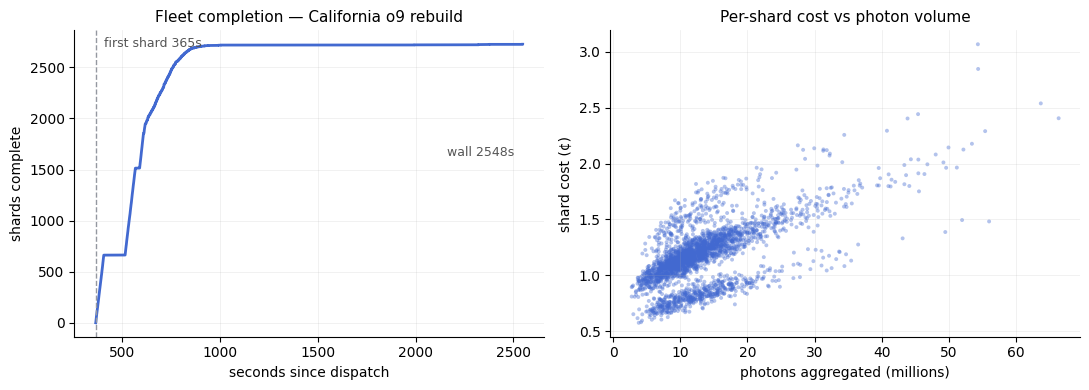

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

t = np.asarray(completions)
ax1.step(t, np.arange(1, len(t) + 1), where="post", color="#4269d0", lw=2)
ax1.axvline(t[0], color="#9498a0", lw=1, ls="--")
ax1.annotate(
    f"first shard {t[0]:.0f}s",
    (t[0], len(t)),
    xytext=(6, -2),
    textcoords="offset points",
    fontsize=9,
    color="#555",
)
ax1.annotate(
    f"wall {t[-1]:.0f}s",
    (t[-1], len(t) * 0.6),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color="#555",
)
ax1.set_xlabel("seconds since dispatch")
ax1.set_ylabel("shards complete")
ax1.set_title("Fleet completion — California o9 rebuild", fontsize=11)

ax2.scatter(
    stats.n_obs / 1e6, stats.est_cost_usd * 100, s=8, alpha=0.4, color="#4269d0", edgecolors="none"
)
ax2.set_xlabel("photons aggregated (millions)")
ax2.set_ylabel("shard cost (¢)")
ax2.set_title("Per-shard cost vs photon volume", fontsize=11)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

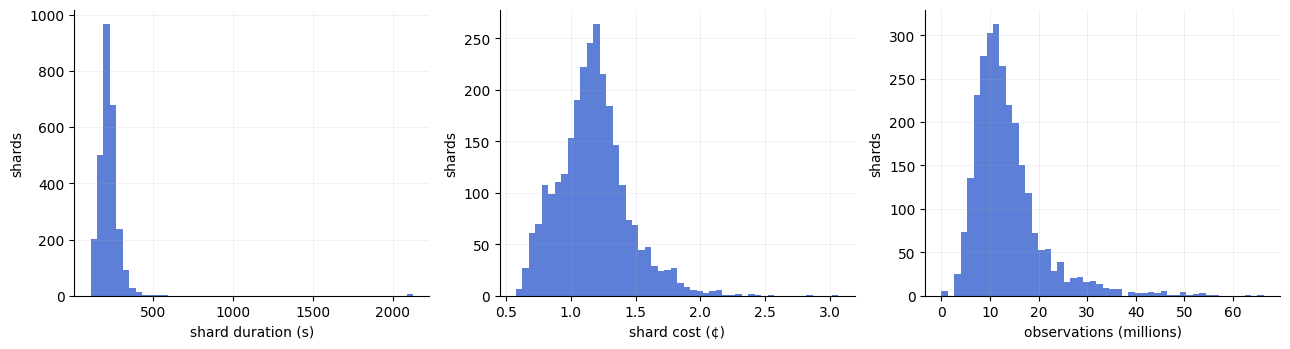

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [
    ("duration_s", "shard duration (s)", 1.0),
    ("est_cost_usd", "shard cost (\u00a2)", 100.0),
    ("n_obs", "observations (millions)", 1e-6),
]
for ax, (col, label, scale) in zip(axes, panels):
    ax.hist(stats[col].dropna() * scale, bins=50, color="#4269d0", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("shards")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

In [41]:
folded = stats.get("spill_blocks_closed")
run_summary = {
    "shards": len(stats),
    "succeeded": int(stats.success.sum()),
    "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
    "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 2)
    if "cells_with_data" in ok
    else "n/a",
    "granule reads": f"{int(stats.n_granules.sum()):,}",
    "lambda-hours": round(float(stats.duration_s.sum()) / 3600, 1),
    "spill volume (GB, to /tmp)": round(float(stats.spill_bytes.fillna(0).sum()) / 2**30, 1)
    if "spill_bytes" in stats
    else "n/a",
    "actual cost (USD)": round(float(billed), 2),
    "shard duration min (median / p95 / max)": f"{stats.duration_s.median() / 60:.1f} / {stats.duration_s.quantile(0.95) / 60:.1f} / {stats.duration_s.max() / 60:.1f}",
    "max_memory_mb (median / max)": f"{stats.max_memory_mb.median():,.0f} / {stats.max_memory_mb.max():,.0f}",
    "spill fold regime (shards)": int((folded.fillna(0) > 0).sum())
    if folded is not None
    else "n/a",
    "latency min (first shard)": round(completions[0] / 60, 2),
    "wall min (full state)": round(completions[-1] / 60, 2),
}
pd.Series(run_summary, name="California o9 rebuild").to_frame()

,California o9 rebuild
shards,2726
succeeded,2721
total_obs (B),36.87
cells_with_data (M),461.52
granule reads,"190,878"
lambda-hours,169.4
"spill volume (GB, to /tmp)",1133.3
actual cost (USD),32.53
shard duration min (median / p95 / max),3.6 / 5.2 / 35.4
max_memory_mb (median / max),"1,207 / 4,051"


In [42]:
# same columns as the SERC variant table, for cross-section comparison
pd.DataFrame(
    {
        "california o9 rebuild (strata, located, temporal, pyramid)": {
            "cost_usd": round(float(billed), 4),
            "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 3)
            if "cells_with_data" in ok
            else None,
            "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
            "latency (min)": round(completions[0] / 60, 2),
            "wall (min)": round(completions[-1] / 60, 2),
        }
    }
).T

,cost_usd,cells_with_data (M),total_obs (B),latency (min),wall (min)
"california o9 rebuild (strata, located, temporal, pyramid)",32.526,461.525,36.87,6.09,42.46


## Timings

In [43]:
(OUT / "timings_write.json").write_text(json.dumps(timings, indent=2))
pd.Series(timings, name="seconds").to_frame()

,seconds
GEDI: CMR L1B query,3.50
GEDI: CMR L2A query,3.55
GEDI: paired shardmap build (o9),0.19
SERC: pyramid variant (run + sweep tail),0.00
SERC: 4 variants (parallel),304.60
California: o9 rebuild,3957.24


## Historical Run

The 0.45-era California o9 build, preserved with its plots for byte-level and
cost comparison against the modern rebuild above. Its store is **kept** at
`california_tdigest_o9.zarr` (never wiped). Differences from the rebuild:
pre-δ=8192 centroid budget, no temporal channel, no located-through-overviews,
pyramid off, pre-epoch semantic hashes (PR #420), and the pre-#460 read path.

## California at o9 — full state, standard tier

The production shape end to end: **strata (signal/noise, located)** aggregation, hive + sharded o9 shards, `process-shard-4096-disk` with spill, sidecar chunk-index in write-through mode, pyramid off. No fat tail at this order (the o8 campaign that proved that lives in `04_california_o8.ipynb`). Dispatched on the **event transport** — at 2,721 shards the status-object channel is what lands the run parquet (the sync transport's inline budget caps out ~500 rows), holds no connections, and makes the run reattachable by id. The store is kept, never wiped.

In [19]:
ca_config = default_config("atl03_tdigest_strata_healpix")
ca_config.output = default_config(
    "atl03_tdigest_healpix_hive"
).output  # hive + sharded, parent_order 9, pyramid off
ca_config.worker = {"memory": 4096, "extra_disk": True}
ca_config.aggregation["streaming"] = {"mode": "spill"}
# write-through sidecar chunk-index: warm for the whole state from the o8 campaign
ca_config.data_source["index"] = {
    "backend": "sidecar",
    "on_miss": "build",
    "store": "s3://sliderule-public-cors/zagg-index/ATL03/007",
}
ca_map = str(OUT / "shardmap_california_o9.json")

print(format_max_cost(max_cost_preview(ca_config, catalog=ca_map)))

Max cost ceiling: ~$130.61 (2721 units x 4 GB x 900s, arm64)


In [20]:
CA_STORE = f"{STORE}/california_tdigest_o9.zarr"  # KEPT across sessions, never wiped

run_ca = Run.from_config(ca_config, shardmap=ca_map, store=CA_STORE, overwrite=True)

t0 = time.perf_counter()
# max_workers: explicit pacing window (the probe clamps to the kernel's fd
# ceiling -- vestigial for the event transport, which holds no sockets); 1800
# sits under the ~1900 account headroom and pulls small shards into wave one
handle_ca = run_ca.dispatch(transport="event", max_workers=1800)
completions = []


def _trace():
    from tqdm.auto import tqdm

    for _ in tqdm(handle_ca.as_completed(), total=len(handle_ca), desc="shards", unit="shard"):
        completions.append(time.perf_counter() - t0)


threading.Thread(target=_trace, name="ca-trace", daemon=True).start()
handle_ca.status()

zagg.runner: Account concurrency: limit=2000, current=17, padding=100, available=1883 -> using 1883 workers
zagg.client: Max cost ceiling: ~$130.61 (2721 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


{'pending': 2721, 'ok': 0, 'failed': 0}

shards:   0%|          | 0/2721 [00:00<?, ?shard/s]

In [28]:
handle_ca.status() | {
    "cost_so_far_usd": round(handle_ca.cost_usd(), 4)
}  # rerun at will while the fleet works

{'pending': 1787, 'ok': 934, 'failed': 0, 'cost_so_far_usd': 7.0528}

In [29]:
handle_ca.wait()  # join: every shard AND the post-run tail (finalize, coverage, stats, sweep)
timings["California: o9 run"] = round(time.perf_counter() - t0, 2)
print(
    f"first shard done at {completions[0]:.1f}s; "
    f"full state at {completions[-1]:.1f}s ({len(completions)} shards)"
)

zagg.runner: Dispatched run stats write (2721 rows, fire-and-forget): s3://sliderule-public/zagg-demo/california_tdigest_o9.zarr/stats_20260804T051621Z_0c56df7ce58644c38bed26415e7deb7e.parquet


first shard done at 321.6s; full state at 891.8s (2721 shards)


Per-shard telemetry lands as a parquet at the store root — the event transport's pointer path carries all 2,721 rows.

In [30]:
from zagg import runner as _runner
from zagg.client import ShardError
from zagg.dispatch import LAMBDA_PRICE_PER_GB_SEC


def _handle_results(handle):
    out = []
    for key, fut in handle.futures.items():
        exc = fut.exception()
        if exc is None:
            out.append(fut.result())
        elif isinstance(exc, ShardError):
            out.append(exc.payload)
        else:
            out.append(
                {
                    "shard_key": key,
                    "status_code": None,
                    "body": {},
                    "error": f"{type(exc).__name__}: {exc}",
                    "retries": None,
                }
            )
    return out


def fetch_run_stats(store_path, handle=None):
    """The store parquet when present, else rows rebuilt from the handle."""
    bucket, _, prefix = store_path.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    objs = s3.list_objects_v2(Bucket=bucket, Prefix=f"{prefix}/stats_").get("Contents", [])
    if objs:
        key = max(o["Key"] for o in objs)  # timestamp-first names sort chronologically
        return pq.read_table(
            io.BytesIO(s3.get_object(Bucket=bucket, Key=key)["Body"].read())
        ).to_pandas()
    assert handle is not None, "no stats parquet and no handle to rebuild from"
    rows, _ = _runner._lambda_result_rows(_handle_results(handle), run_id="notebook-rebuild")
    return pd.DataFrame(rows)


stats = fetch_run_stats(handle_ca.store_path, handle=handle_ca)
ok = stats[stats.success.fillna(False)]
fails = stats[~stats.success.fillna(False)]
memory_gb = _runner._worker_memory_gb(ca_config)
billed = stats.est_cost_usd.fillna(stats.duration_s * memory_gb * LAMBDA_PRICE_PER_GB_SEC).sum()
print(
    f"worker-reported cost ${stats.est_cost_usd.sum():.2f}; billed estimate incl. "
    f"{len(fails)} failed attempts ${billed:.2f} | "
    f"{stats.duration_s.sum():,.0f} lambda-seconds, {ok.n_obs.sum() / 1e9:.2f}B photons"
)
if len(fails):
    print("failure classes:")
    print(fails.error_class.str[:60].value_counts().to_string())
stats[["duration_s", "n_obs", "n_granules", "max_memory_mb", "est_cost_usd"]].describe().round(4)

worker-reported cost $21.54; billed estimate incl. 0 failed attempts $21.54 | 403,888 lambda-seconds, 37.15B photons


,duration_s,n_obs,n_granules,max_memory_mb,est_cost_usd
count,2721.0000,2.721000e+03,2721.0000,2721.0000,2721.0000
mean,148.4336,1.365206e+07,70.0570,1089.7755,0.0079
std,33.6373,7.461750e+06,8.1527,406.2562,0.0018
min,77.0760,2.728726e+06,54.0000,438.6016,0.0041
25%,126.7571,9.075554e+06,64.0000,824.7031,0.0068
50%,144.8831,1.203212e+07,67.0000,1014.8594,0.0077
75%,163.1371,1.595650e+07,76.0000,1245.5469,0.0087
max,365.0188,7.216157e+07,102.0000,3974.6719,0.0195


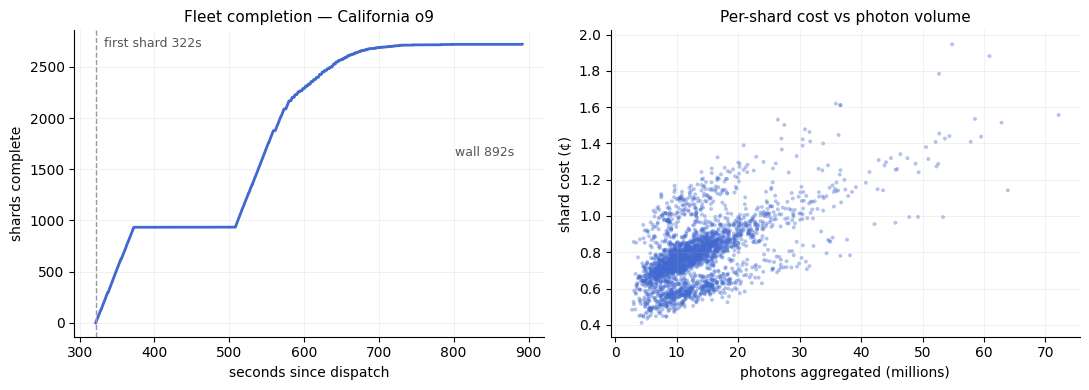

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

t = np.asarray(completions)
ax1.step(t, np.arange(1, len(t) + 1), where="post", color="#4269d0", lw=2)
ax1.axvline(t[0], color="#9498a0", lw=1, ls="--")
ax1.annotate(
    f"first shard {t[0]:.0f}s",
    (t[0], len(t)),
    xytext=(6, -2),
    textcoords="offset points",
    fontsize=9,
    color="#555",
)
ax1.annotate(
    f"wall {t[-1]:.0f}s",
    (t[-1], len(t) * 0.6),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color="#555",
)
ax1.set_xlabel("seconds since dispatch")
ax1.set_ylabel("shards complete")
ax1.set_title("Fleet completion — California o9", fontsize=11)

ax2.scatter(
    stats.n_obs / 1e6, stats.est_cost_usd * 100, s=8, alpha=0.4, color="#4269d0", edgecolors="none"
)
ax2.set_xlabel("photons aggregated (millions)")
ax2.set_ylabel("shard cost (¢)")
ax2.set_title("Per-shard cost vs photon volume", fontsize=11)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

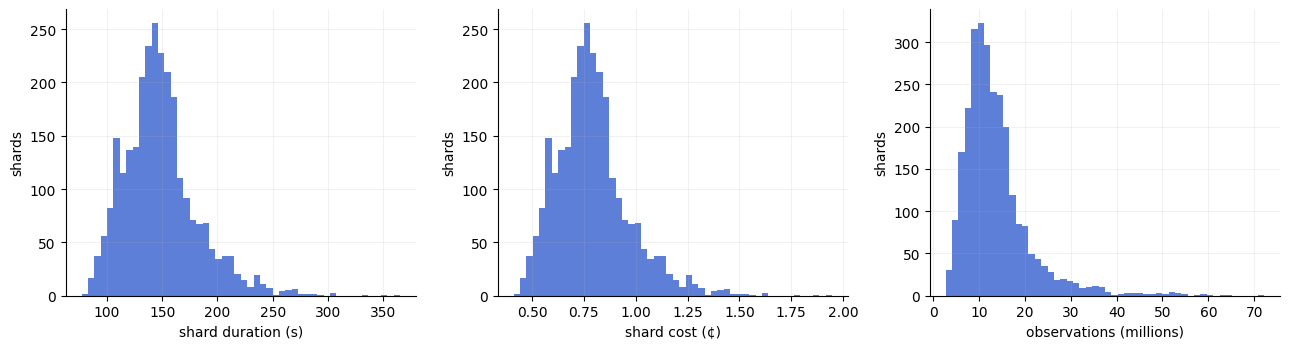

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [
    ("duration_s", "shard duration (s)", 1.0),
    ("est_cost_usd", "shard cost (\u00a2)", 100.0),
    ("n_obs", "observations (millions)", 1e-6),
]
for ax, (col, label, scale) in zip(axes, panels):
    ax.hist(stats[col].dropna() * scale, bins=50, color="#4269d0", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("shards")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

In [33]:
folded = stats.get("spill_blocks_closed")
run_summary = {
    "shards": len(stats),
    "succeeded": int(stats.success.sum()),
    "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
    "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 2)
    if "cells_with_data" in ok
    else "n/a",
    "granule reads": f"{int(stats.n_granules.sum()):,}",
    "lambda-hours": round(float(stats.duration_s.sum()) / 3600, 1),
    "spill volume (GB, to /tmp)": round(float(stats.spill_bytes.fillna(0).sum()) / 2**30, 1)
    if "spill_bytes" in stats
    else "n/a",
    "actual cost (USD)": round(float(billed), 2),
    "shard duration min (median / p95 / max)": f"{stats.duration_s.median() / 60:.1f} / {stats.duration_s.quantile(0.95) / 60:.1f} / {stats.duration_s.max() / 60:.1f}",
    "max_memory_mb (median / max)": f"{stats.max_memory_mb.median():,.0f} / {stats.max_memory_mb.max():,.0f}",
    "spill fold regime (shards)": int((folded.fillna(0) > 0).sum())
    if folded is not None
    else "n/a",
    "latency min (first shard)": round(completions[0] / 60, 2),
    "wall min (full state)": round(completions[-1] / 60, 2),
}
pd.Series(run_summary, name="California o9").to_frame()

,California o9
shards,2721
succeeded,2721
total_obs (M),37147.3
cells_with_data (M),462.33
granule reads,"190,625"
lambda-seconds,"403,888"
actual cost (USD),21.54
shard duration min (median / p95 / max),2.4 / 3.5 / 6.1
max_memory_mb (median / max),"1,015 / 3,975"
spill fold regime (shards),0


In [34]:
# same columns as the SERC variant table, for cross-section comparison
pd.DataFrame(
    {
        "california o9 (strata, located)": {
            "cost_usd": round(float(billed), 4),
            "cells_with_data (M)": round(float(ok.cells_with_data.sum()) / 1e6, 3)
            if "cells_with_data" in ok
            else None,
            "total_obs (B)": round(float(ok.n_obs.sum()) / 1e9, 2),
            "latency (min)": round(completions[0] / 60, 2),
            "wall (min)": round(completions[-1] / 60, 2),
        }
    }
).T

,cost_usd,cells_with_data (M),total_obs (M),latency (min),wall (min)
"california o9 (strata, located)",21.5408,462.328,37147.26,5.36,14.86
